In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import robot_vlp.data_collection.experment_processing as ep
import robot_vlp.modeling.gen_cnc_vlp_model as vlp
import robot_vlp.data_collection.communication as c
import pickle

from robot_vlp.config import EXPERIMENT_DATA_DIR, VLP_MODELS_DIR


%load_ext autoreload
%autoreload 2

2025-01-07 07:24:52.477 | INFO     | robot_vlp.config:<module>:11 - PROJ_ROOT path is: /Users/tyrelglass/PhD/Repositories/robot-vlp


In [2]:
vlp_models = vlp.load_vlp_models()

2025-01-07 07:24:55.325823: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-01-07 07:24:55.325855: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-01-07 07:24:55.325859: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-01-07 07:24:55.325882: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-01-07 07:24:55.325896: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
vlp_model = vlp_models['high_acc']

input_file = EXPERIMENT_DATA_DIR/'Robot/exp07.csv'
df = ep.process_robot_exp_file(input_file, vlp_model)

2025-01-07 07:24:58.272 | SUCCESS  | robot_vlp.data_collection.experment_processing:process_robot_exp_file:69 - opending file: 
 1/27 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step

/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
2025-01-07 07:25:02.542841: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


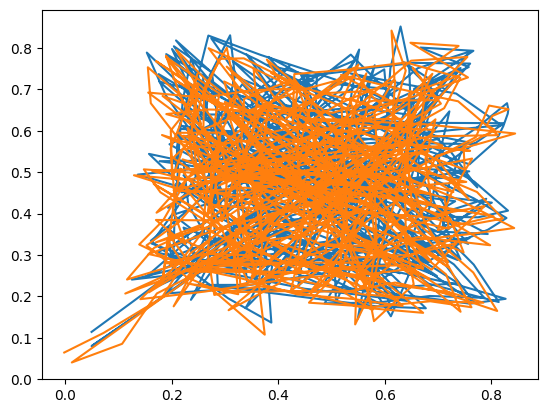

In [4]:
plt.plot(df['x_hist'], df['y_hist'])
plt.plot(df['vlp_x_hist'], df['vlp_y_hist'])

In [5]:
turn_df = df[df['encoder_heading_change'] != 0]

(0.0, 10.0)

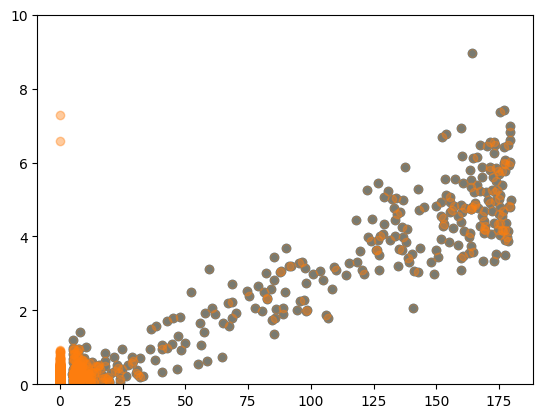

In [6]:
plt.scatter(turn_df['encoder_heading_change'].abs(), turn_df['encoder_heading_change_err'].abs())
plt.scatter(df['encoder_heading_change'].abs(), df['encoder_heading_change_err'].abs(), alpha = 0.4)
plt.ylim(0,10)

In [7]:
_ = plt.hist(filter_outliers(turn_df['encoder_heading_change_err']/turn_df['vive_heading_change'], threshold= 4), bins = 70)
_ = plt.hist(filter_outliers(df['encoder_heading_change_err']/df['vive_heading_change'], threshold= 4), bins = 70, alpha = 0.4)

NameError: name 'filter_outliers' is not defined

In [ ]:
plt.hist(filter_outliers(df['encoder_location_change_err'], threshold= 5), bins = 50)
plt.axvline(0, c = 'r')

In [8]:
df['vlp_x_err'] = df['x_hist'] - df['vlp_x_hist']
df['vlp_y_err'] = df['y_hist'] - df['vlp_y_hist']


In [9]:
def filter_outliers(data, threshold=1.5):

    data = np.asarray(data)  # Ensure input is a NumPy array
    data = data[~np.isnan(data)] 
    q1 = np.percentile(data, 25)  # First quartile (Q1)
    q3 = np.percentile(data, 75)  # Third quartile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)
    
    # Calculate bounds for non-outliers
    lower_bound = q1 - threshold * iqr
    upper_bound = q3 + threshold * iqr
    
    # Filter the data
    filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
    return filtered_data


# VLP statistics
vlp_x_mean = df['vlp_x_err'].mean()
vlp_x_var = df['vlp_x_err'].var()
vlp_y_mean = df['vlp_y_err'].mean()
vlp_y_var = df['vlp_y_err'].var()


# Encoder heading change error
encoder_heading_mean = filter_outliers(turn_df['encoder_heading_change_err'], threshold=2).mean()
encoder_heading_var = filter_outliers(turn_df['encoder_heading_change_err'], threshold=2).var()

# Encoder location change error
encoder_location_mean = filter_outliers(df['encoder_location_change_err'], threshold=2).mean()
encoder_location_var = filter_outliers(df['encoder_location_change_err'],threshold=2).var()

print(f"Encoder Heading Error: Mean = {encoder_heading_mean}, Variance = {encoder_heading_var}")
print(f"Encoder Location Error: Mean = {encoder_location_mean}, Variance = {encoder_location_var}")

print(f"VLP X Error: Mean = {vlp_x_mean}, Variance = {vlp_x_var}")
print(f"VLP Y Error: Mean = {vlp_y_mean}, Variance = {vlp_y_var}")

Encoder Heading Error: Mean = -0.44681279633942345, Variance = 9.537921194761365
Encoder Location Error: Mean = 0.0011211501632430146, Variance = 4.391649206989878e-06
VLP X Error: Mean = 0.015867253800511946, Variance = 0.00016236174897253078
VLP Y Error: Mean = 0.014215459256541368, Variance = 0.0001567524039794866


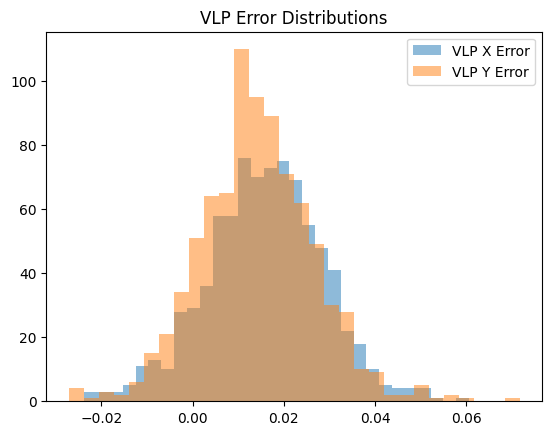

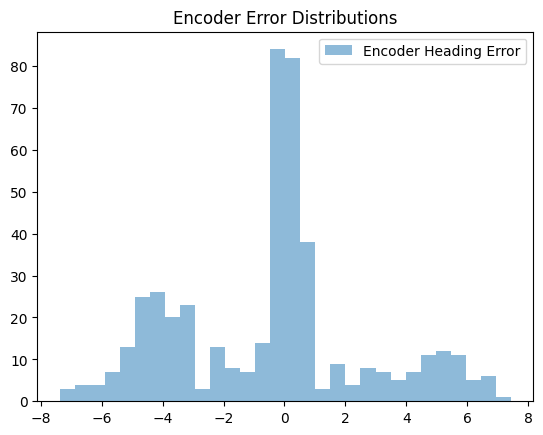

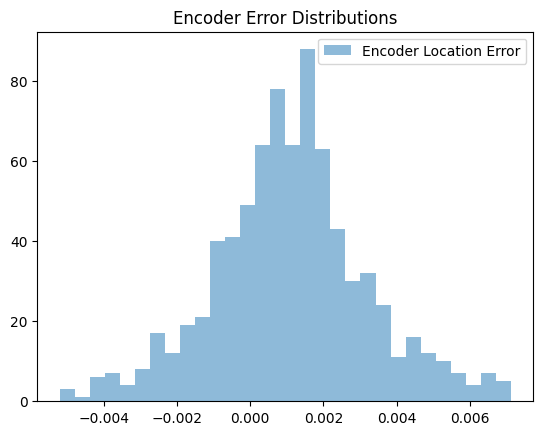

In [10]:
import matplotlib.pyplot as plt

# Plot VLP error distributions
plt.hist(df['vlp_x_err'], bins=30, alpha=0.5, label='VLP X Error')
plt.hist(df['vlp_y_err'], bins=30, alpha=0.5, label='VLP Y Error')
plt.legend()
plt.title('VLP Error Distributions')
plt.show()

# Plot encoder error distributions
plt.hist(filter_outliers(turn_df['encoder_heading_change_err'], threshold= 2), bins=30, alpha=0.5, label='Encoder Heading Error')
# plt.hist(filter_outliers(df['encoder_location_change_err'], threshold=2), bins=30, alpha=0.5, label='Encoder Location Error')
plt.legend()
plt.title('Encoder Error Distributions')
plt.show()


# Plot encoder error distributions
# plt.hist(filter_outliers(turn_df['encoder_heading_change_err'], threshold= 2), bins=30, alpha=0.5, label='Encoder Heading Error')
plt.hist(filter_outliers(df['encoder_location_change_err'], threshold=2), bins=30, alpha=0.5, label='Encoder Location Error')
plt.legend()
plt.title('Encoder Error Distributions')
plt.show()

In [11]:
encoder_heading_var

9.537921194761365

In [50]:
import numpy as np

def degrees_to_radians(deg):
    return np.deg2rad(deg)

def normalize_angle_deg(angle):
    """Normalize an angle in degrees to the range [-180, 180]."""
    return (angle + 180) % 360 - 180

def ekf_predict(x_prev, P_prev, d, delta_theta, Q):
    """
    EKF Prediction Step for angles in degrees.
    Args:
        x_prev: Previous state vector [x, y, theta]
        P_prev: Previous covariance matrix
        d: Distance traveled
        delta_theta: Change in heading (degrees)
        Q: Process noise covariance matrix
    Returns:
        x_pred: Predicted state
        P_pred: Predicted covariance
    """
    # Extract previous state
    x, y, theta = x_prev

    # Normalize the new heading angle
    theta_rotated = normalize_angle_deg(theta + delta_theta)

    # Convert to radians for trigonometric calculations
    theta_rotated_rad = np.radians(theta_rotated)

    # Predict state
    x_pred = np.array([
        x + d * np.sin(theta_rotated_rad),
        y + d * np.cos(theta_rotated_rad),
        theta_rotated
    ])

    # Compute Jacobian of motion model
    F_k = np.array([
        [1, 0, -d * np.cos(theta_rotated_rad)],
        [0, 1, -d * np.sin(theta_rotated_rad)],
        [0, 0, 1]
    ])

    # Predict covariance
    P_pred = F_k @ P_prev @ F_k.T + Q

    return x_pred, P_pred

def ekf_update_with_vlp_heading(x_pred, P_pred, z_meas, R, last_position, sigma_vlp_heading, sigma_encoder_heading):
    """
    EKF Update Step with VLP heading correction.
    Args:
        x_pred: Predicted state vector [x, y, theta]
        P_pred: Predicted covariance matrix (3x3)
        z_meas: Measurement vector [x_vlp, y_vlp]
        R: Measurement noise covariance matrix (2x2)
        last_position: Previous position [x_last, y_last]
        sigma_vlp_heading: Standard deviation of VLP-derived heading
        sigma_encoder_heading: Standard deviation of encoder heading
    Returns:
        x_upd: Updated state vector
        P_upd: Updated covariance matrix
    """
    # Measurement model for position
    H_k = np.array([
        [1, 0, 0],  # Maps x to measurement space
        [0, 1, 0]   # Maps y to measurement space
    ])

    # Predicted measurement
    z_pred = H_k @ x_pred  # Only x and y are involved

    # Innovation (residual)
    y_k = z_meas - z_pred

    # Innovation covariance
    S_k = H_k @ P_pred @ H_k.T + R

    # Kalman Gain
    K_k = P_pred @ H_k.T @ np.linalg.inv(S_k)

    # State Update (x and y)
    x_upd = x_pred + K_k @ y_k

    # Calculate VLP-derived heading
    delta_x = x_upd[0] - last_position[0]
    delta_y = x_upd[1] - last_position[1]
    theta_vlp = np.degrees(np.arctan2(delta_y, delta_x))
    theta_vlp = normalize_angle_deg(theta_vlp)

    # Predicted heading from encoder
    theta_encoder = x_pred[2]

    # Compute weights based on uncertainties
    w_vlp = 1 / sigma_vlp_heading**2
    w_encoder = 1 / sigma_encoder_heading**2
    total_weight = w_vlp + w_encoder
    w_vlp /= total_weight
    w_encoder /= total_weight

    # Weighted heading update
    x_upd[2] = normalize_angle_deg(w_vlp * theta_vlp + w_encoder * theta_encoder)

    # Covariance Update
    P_upd = (np.eye(len(P_pred)) - K_k @ H_k) @ P_pred

    return x_upd, P_upd

# Initialize variables
x_init = 0
y_init = 0
theta_init = 0

x = np.array([x_init, y_init, theta_init])  # Initial state (angles in degrees)
P = np.diag([encoder_location_var, encoder_location_var, encoder_heading_var])  # Initial covariance
last_position = np.array([x_init, y_init])  # Track last position

# Adjust process noise (encoder)
Q = np.diag([
    encoder_location_var * 20.0,  # Increase trust in VLP by increasing process noise
    encoder_location_var * 20.0,
    encoder_heading_var * 20.0
])

# Adjust measurement noise (VLP)
R = np.diag([
    vlp_x_var * 0.005,  # Reduce VLP noise variance
    vlp_y_var * 0.005
])

# Adjust heading weights
sigma_vlp_heading = 0.00005  # Lower value: higher trust in vector heading
sigma_encoder_heading = np.sqrt(encoder_heading_var) * 1.5  # Higher value: less trust in encoder

res_lst = [x]

for index, step in df.iterrows():
    # Get encoder measurements
    d = step['encoder_location_change']
    delta_theta = step['encoder_heading_change']  # In degrees

    # Get VLP measurements
    z_meas = np.array([step['vlp_x_hist'], step['vlp_y_hist']])

    # EKF Prediction
    x_pred, P_pred = ekf_predict(x, P, d, delta_theta, Q)

    # EKF Update with heading correction from motion vector
    x, P = ekf_update_with_vlp_heading(x_pred, P_pred, z_meas, R, last_position, sigma_vlp_heading, sigma_encoder_heading)

    # Normalize heading angle
    x[2] = normalize_angle_deg(x[2])

    # Update last position
    last_position = x[:2]

    res_lst.append(x)


In [51]:
pre = np.array(res_lst[1:])

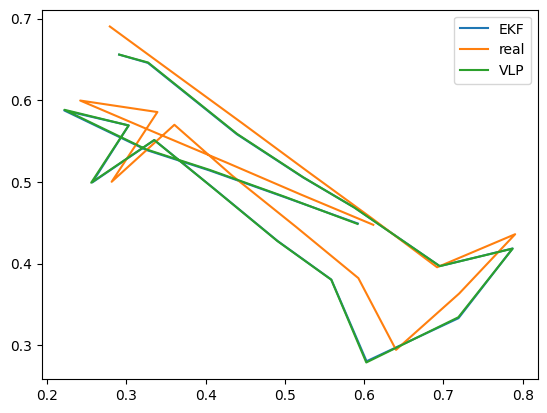

In [52]:
s = 150
e = s+ 20
plt.plot(pre[s:e,0], pre[s:e,1], label = 'EKF')
plt.plot(df['x_hist'].iloc[s:e], df['y_hist'].iloc[s:e], label = 'real')
plt.plot(df['vlp_x_hist'].iloc[s:e], df['vlp_y_hist'].iloc[s:e], label = 'VLP')
plt.legend()


In [53]:
df[['EKF_x', 'EKF_y', 'EKF_heading']] = pre

In [54]:
def calc_EKF_pos_err(df):
    x = df['x_hist']
    y = df['y_hist']
    ex = df['EKF_x']
    ey = df['EKF_y']
    return np.sqrt(np.square(x - ex) + np.square(y - ey))
def calc_EKF_heading_err(df):
    heading = df['heading_hist']
    eheading = df['EKF_heading']
    return np.array([c.normalize_angle(a) for a in (heading - eheading)])

def calc_pos_err(df):
    x = df['x_hist']
    y = df['y_hist']
    ex = df['encoder_x_hist']
    ey = df['encoder_y_hist']
    return np.sqrt(np.square(x - ex) + np.square(y - ey))
def calc_heading_err(df):
    heading = df['heading_hist']
    eheading = df['encoder_heading_hist']
    return np.array([c.normalize_angle(a)for a in (heading - eheading)])

def calc_vlp_pos_err(df):
    x = df['x_hist']
    y = df['y_hist']
    ex = df['vlp_x_hist']
    ey = df['vlp_y_hist']
    return np.sqrt(np.square(x - ex) + np.square(y - ey))
def calc_vlp_heading_err(df):
    heading = df['heading_hist']
    eheading = df['vlp_heading_hist']
    return np.array([c.normalize_angle(a) for a in (heading - eheading)])


In [55]:
df['EKF_pos_err'] = calc_EKF_pos_err(df)
df['encoder_pos_err'] = calc_pos_err(df)
df['vlp_pos_err'] = calc_vlp_pos_err(df)

df['EKF_heading_err'] = calc_EKF_heading_err(df)
df['encoder_heading_err'] = calc_heading_err(df)
df['vlp_heading_err'] = calc_vlp_heading_err(df)

In [56]:
df['EKF_heading_err'].mean(), df['encoder_heading_err'].mean(), df['vlp_heading_err'].mean()

(7.84105213619092, -24.97790961991913, -1.2766756101220327)

0.0259384464507572


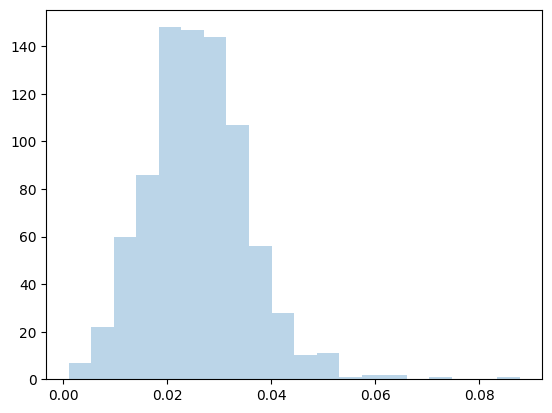

In [57]:
print(df['EKF_pos_err'].mean())
_ = plt.hist(df['EKF_pos_err'], bins = 20, alpha = 0.3)




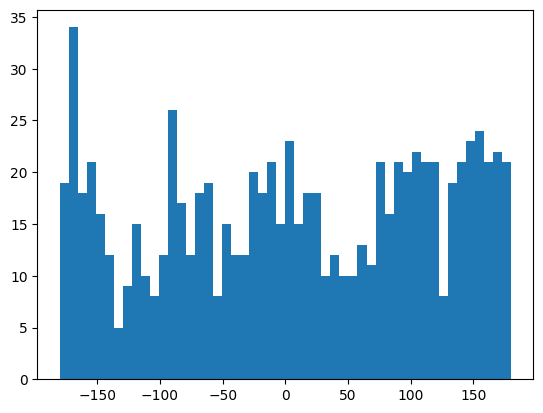

In [58]:
df['EKF_heading_err'].mean()
_ = plt.hist(df['EKF_heading_err'], bins = 50)

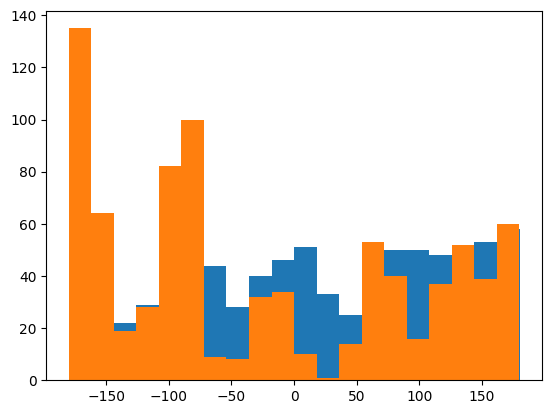

In [59]:
_ = plt.hist(df['EKF_heading_err'], bins = 20)
_ = plt.hist(df['encoder_heading_err'], bins = 20)

<Axes: >

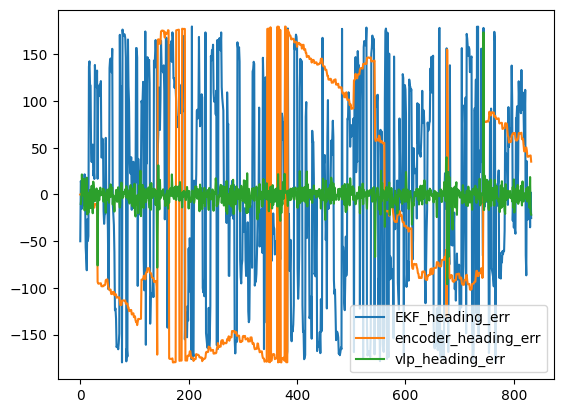

In [60]:
df[['EKF_heading_err','encoder_heading_err','vlp_heading_err']].plot()

<Axes: >

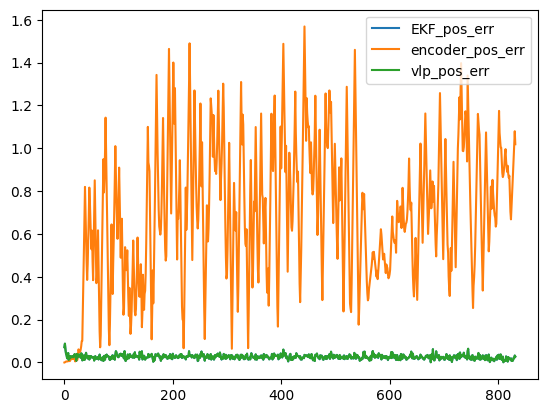

In [62]:
df[['EKF_pos_err','encoder_pos_err','vlp_pos_err']].plot()

In [63]:
s = 100
e = s + 50
df[['EKF_heading','encoder_heading_hist', 'vlp_heading_hist','heading_hist']].iloc[s:e]

,EKF_heading,encoder_heading_hist,vlp_heading_hist,heading_hist
100,-133.355932,5.229383,-136.844238,-125.316388
101,-159.019555,-0.943456,-110.827744,-131.331084
102,27.255947,174.629736,63.392902,39.881055
103,-34.286881,-100.978730,124.159973,122.522982
104,-34.048311,-100.978730,124.130020,122.726577
105,146.508274,72.918977,-56.306103,-66.913371
106,-86.414580,-47.539576,176.117371,175.710792
107,15.274984,-173.465502,73.574005,53.417646
108,36.770639,-173.465502,53.610161,53.067028
109,46.658095,-173.465502,43.202587,53.178812
